In [2]:
import salvus.namespace as sn
import numpy as np

import sys
from pathlib import Path
path_to_add = str(Path.cwd() / "tomography")
if path_to_add not in sys.path:
    sys.path.append(path_to_add)
    

from my_code.utilities import *
from pathlib import Path
import salvus
import salvus.mesh.layered_meshing as lm
from datetime import datetime
import math
import salvus.flow.simple_config as sc

from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)

import xarray as xr

# # Directories in WSL
# PROJECT_DIR = '/home/oliver/workspace/Salvus/acoustic_model/Project'
# IMAGE_DIR = '/home/oliver/workspace/Salvus/acoustic_model/image'
# DATA_DIR = '/home/oliver/workspace/Salvus/acoustic_model/data'


# Directories in Windows
PROJECT_DIR_WIN = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project'
DATA_DIR_WIN = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/data'
IMAGE_DIR_WIN = '/home/b6as/oliverwfy.b6as/workspace/acoustic_model/image'


# create dir if it does not exist

Path(PROJECT_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(IMAGE_DIR_WIN).mkdir(parents=True, exist_ok=True)
Path(DATA_DIR_WIN).mkdir(parents=True, exist_ok=True)


--> Server: 'https://l.mondaic.com/licensing_server', User: 'bristol.support', Group: 'UniversityOfBristol'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.43 seconds]


In [3]:
# salvus site 
SITE_NAME = "isambard_oliver"
RANKS = 8

CENTRAL_FREQUENCY = 2e4  # Hz
f_c = 2e4  # central frequency in Hz
PROJECT_NAME = 'acoustic_forward_5paris'


VP = 5000.0
RHO = 2600.0


x0, x1 = 0.0, 1
y0, y1 = 0.0, 1


domain = sn.domain.dim2.BoxDomain(x0=x0, x1=x1, y0=y0, y1=y1)

p = sn.Project.from_domain(
    path=Path(PROJECT_DIR_WIN, PROJECT_NAME), domain=domain, load_if_exists=True
)



# # Define layers
# layer_ls = [{ 'rho': RHO, 'vp': VP , 'd':1.0}, { 'rho': RHO, 'vp': VP*1.1 , 'd':2.0}, { 'rho': RHO, 'vp': VP*1.3 , 'd':2.0}, { 'rho': RHO, 'vp': VP*1.5 , 'd':2.0}]

# hyperplane_ls = np.cumsum([layer['d'] for layer in layer_ls][::-1])


# layered_model_ls = []

# for i in range(len(layer_ls)):
#     layered_model_ls.append(sn.material.acoustic.Velocity.from_params(rho=layer_ls[i]['rho'], vp=layer_ls[i]['vp']))
#     layered_model_ls.append(sn.layered_meshing.interface.Hyperplane.at(hyperplane_ls[i]))

# layered_model_ls.pop() # delete the last hyperplane


# layered_model = lm.LayeredModel(layered_model_ls)


# vp_grad = xr.DataArray(
#     np.linspace(1.0, 1.5, 6), [("y", np.linspace(1.0, 0.0, 6))]
# )




m_true = sn.layered_meshing.LayeredModel([
    sn.material.from_params(rho=RHO, vp=VP),
    sn.layered_meshing.interface.Hyperplane.at(0.6),
    sn.material.from_params(rho=RHO, vp=1.5*VP),
    sn.layered_meshing.interface.Hyperplane.at(0.4),
    sn.material.from_params(rho=RHO, vp=VP),
    ])



# mesh resolution parameters
elements_per_wavelength = 3  # number of elements per wavelength
model_order = 4  # model order for the mesh


# absorbing boundary parameters
reference_velocity = 5000           # wave velocity in the absorbing boundary layer
number_of_wavelengths=2            # number of wavelengths to pad the domain by
reference_frequency = CENTRAL_FREQUENCY*2           # reference frequency for the distance calculation
free_surfaces = ['y0', 'y1']       # free surfaces, absorbing boundaries are applied for the rest






m_homo = sn.material.from_params(rho=RHO, vp=VP)

# adding absorbing boundary conditions to the layered model
model_ab_homo = sn.layered_meshing.MeshingProtocol(
    m_homo,
    ab=salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
        free_surface=free_surfaces,
        number_of_wavelengths=number_of_wavelengths,
        reference_velocity=reference_velocity,
        reference_frequency=reference_frequency,
    ),
)

# create mesh 
mesh_homo = lm.mesh_from_domain(
    domain=domain,
    model=model_ab_homo,
    mesh_resolution=sn.MeshResolution(
        reference_frequency=reference_frequency, elements_per_wavelength=elements_per_wavelength, model_order=model_order
    ),
)





# adding absorbing boundary conditions to the layered model
model_ab = sn.layered_meshing.MeshingProtocol(
    m_true,
    ab=salvus.mesh.simple_mesh.basic_mesh.AbsorbingBoundaryParameters(
        free_surface=free_surfaces,
        number_of_wavelengths=number_of_wavelengths,
        reference_velocity=reference_velocity,
        reference_frequency=reference_frequency,
    ),
)


# create mesh 
mesh = lm.mesh_from_domain(
    domain=domain,
    model=model_ab,
    mesh_resolution=sn.MeshResolution(
        reference_frequency=reference_frequency, elements_per_wavelength=elements_per_wavelength, model_order=model_order
    ),
)

mesh

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-03-24 14:29:07,461] INFO: Loading project from /home/b6as/oliverwfy.b6as/workspace/acoustic_model/Project/acoustic_forward_5paris.


In [4]:
aplitude_ratio=1e5

s_loc = (0.5, 0.3)
# r_loc = [(i, 1.0) for i in np.linspace(0.2, 0.8, 5)]
r_loc = [(0.5, 0.7)]

receivers = [sn.simple_config.receiver.cartesian.Point2D(x=i[0], y=i[1], station_code=f"R{j+1}", fields=["phi"]) for j, i in enumerate(r_loc)]

source = sn.simple_config.source.cartesian.ScalarPoint2D(x=s_loc[0], y=s_loc[1], f=aplitude_ratio)


p.add_to_project(
    sn.Event(event_name="single_pair", sources=source, receivers=receivers)
)


[2026-03-24 14:29:14,401] INFO: An event with name 'single_pair' and identical content already exists in the project. Nothing will be done.


In [5]:
"""
Configuration from parameters

"""

end_time = 2e-4
start_time= 0
sampling_rate_in_hertz = CENTRAL_FREQUENCY* 100 

time_shift_in_seconds=1/f_c
# simulation of homogeneous model
simulation_name = 'forward_simulation_homogeneous_model'

wavelet = sn.simple_config.stf.Ricker(center_frequency=f_c, time_shift_in_seconds=time_shift_in_seconds)     # wavelet (input source time function) 
# wavelet = sn.simple_config.stf.Ricker(center_frequency=f_c)     # wavelet (input source time function) 



# waveform simulation configuration
waveform_config = sn.WaveformSimulationConfiguration(
        start_time_in_seconds=start_time,
        end_time_in_seconds=end_time,
        time_step_in_seconds=1/sampling_rate_in_hertz
        )

# event configuaration
event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
    )



sim_config = sn.UnstructuredMeshSimulationConfiguration(
    unstructured_mesh=mesh_homo,
    name=simulation_name,
    event_configuration=event_config,
    )



# add simulation configuration to Project
p.add_to_project(
    sim_config, overwrite=True
    )











# simulation of layered model 
simulation_name = 'forward_simulation_layred_model'



# waveform simulation configuration
waveform_config = sn.WaveformSimulationConfiguration(
        start_time_in_seconds=start_time,
        end_time_in_seconds=end_time,
            time_step_in_seconds=1/sampling_rate_in_hertz

        )

# event configuaration
event_config = sn.EventConfiguration(
    wavelet=wavelet,
    waveform_simulation_configuration=waveform_config,
    )



sim_config = sn.UnstructuredMeshSimulationConfiguration(
    unstructured_mesh=mesh,
    name=simulation_name,
    event_configuration=event_config,
    )



# add simulation configuration to Project
p.add_to_project(
    sim_config, overwrite=True
    )


# visualization of mesh and simulation set-up
p.viz.nb.simulation_setup(
    simulation_configuration=simulation_name, events=p.events.list()
    )



[2026-03-24 14:29:20,408] INFO: Deleting existing `forward_simulation_homogeneous_model` entity of type `simulation_configuration` ...


[2026-03-24 14:29:20,477] INFO: Deleting existing `forward_simulation_layred_model` entity of type `simulation_configuration` ...


In [6]:
# dofs =  mesh.number_of_nodes
# print(f'Start simulation: {simulation_name}')
# print(f'Dofs (number of nodes): {dofs}')


# simulation_name = 'forward_simulation_homogeneous_model'
simulation_name = 'forward_simulation_layred_model'



def forward_simulation(simulation_name, events, 
                       fields = None, sampling_interval_in_time_steps=10):
    if fields:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            extra_output_configuration={
                "volume_data": {
                    "sampling_interval_in_time_steps":
                        sampling_interval_in_time_steps,
                    "fields": 
                        fields,
                },
            },
            delete_conflicting_previous_results=True,
        )
    else:
        p.simulations.launch(
            ranks_per_job=RANKS,
            site_name=SITE_NAME,
            events=events,
            simulation_configuration=simulation_name,
            delete_conflicting_previous_results=True,
        )

    
    

"""
Launch simulations

"""

start_time = datetime.now()


# p.simulations.launch(
#     ranks_per_job=RANKS,
#     site_name=SITE_NAME,
#     events=p.events.list(),
#     simulation_configuration=simulation_name,
#     delete_conflicting_previous_results=True,
#     )


event = 'single_pair'

forward_simulation(
    simulation_name="forward_simulation_layred_model",
    events=event,
    fields = None)

p.simulations.query(block=True)

forward_simulation  (
    simulation_name="forward_simulation_homogeneous_model",
    events=event,
    fields = ["phi_tt"],
    sampling_interval_in_time_steps=10)

p.simulations.query(block=True)

end_time = datetime.now()


execution_time_seconds = (end_time - start_time).total_seconds()
minutes = int(execution_time_seconds // 60)  # Extract minutes
seconds = execution_time_seconds % 60  # Extract remaining seconds

print(f"Execution time: {minutes} minutes and {seconds:.2f} seconds")

[2026-03-24 14:29:27,811] INFO: Data for 1 event(s) already exists. They will not be submitted again.


VBox()

[2026-03-24 14:29:27,859] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().


VBox()

Execution time: 0 minutes and 0.46 seconds


In [ ]:
event = 'single_pair'


def extract_data(simulation, events, receiver_field='phi', field=None):
    ed = p.waveforms.get(
    data_name=simulation, 
    events=events)[0]
    
    data = ed.get_waveform_data_xarray(receiver_field=receiver_field)
    wavefield = None
    if field:
        wavefield  = wavefield_output_to_xarray(
        ed.get_wavefield_output(output_type='volume', field=field), p.simulations.get_mesh(simulation).points).T
        
    return data, wavefield
    
phi_homo, phi_tt_homo = extract_data(
    simulation='forward_simulation_homogeneous_model', 
    events=event, 
    receiver_field='phi', 
    field='phi_tt')


phi_obs, _ = extract_data(
    simulation='forward_simulation_layred_model', 
    events=event, 
    receiver_field='phi', 
    field=None)



def misfit_adjoint_source(u_obs, u, event=False, iteration=0):
    sampling_rate = u_obs.sampling_rate_in_hertz
    start_time = u_obs.time[0]
    end_time = u_obs.time[-1]
    
    diff = u_obs - u
    misfit = 1/2 * 1/sampling_rate * (diff**2).sum() 
    f_adj = -np.flip(diff, axis=1)
    event_config_adj = None
    
    if event:
        rxs, srcs = p.events.get(event).receivers, p.events.get(event).sources
        rxs_adj_loc, src_adj_loc = [r.location for r in srcs], [t.location for t in rxs] 
        stf_adj_ls = [sc.stf.Custom.from_array(
            np.array(f_adj[i]),
            sampling_rate_in_hertz=sampling_rate_in_hertz,
            start_time_in_seconds=0.0,
        ) for i in range(len(src_adj_loc))]
        
        srcs_adj = [sn.simple_config.source.cartesian.ScalarPoint2D(
            x=tx[0], y=tx[1], f=1) 
                    for tx in src_adj_loc]

        
        rxs_adj = [sn.simple_config.receiver.cartesian.Point2D(
        x=rx[0], y=rx[1], 
        fields=['phi'], station_code=f"ite: {iteration} adjoint simulation {_i:06d}",
        ) for _i, rx in enumerate(rxs_adj_loc)]

        event_adj = event + f'_adjoint_iteration_{iteration}'
        p.add_to_project(
            sn.Event(event_name=event_adj, sources=srcs_adj, receivers=rxs_adj)
        )
        
        event_config_adj = sn.EventConfiguration(
            wavelet=stf_adj_ls[0],
            waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                start_time_in_seconds=start_time,
                end_time_in_seconds=end_time,
                time_step_in_seconds=1/sampling_rate_in_hertz
            ),
        )
        
    return misfit, f_adj, event_adj,event_config_adj


def adjoint_wavefield(p, event_adj, event_config_adj,
                      model_simulation_name='forward_simulation_homogeneous_model',
                      field='phi', iteration=0,
                      sampling_interval_in_time_steps=10):
    """
    Run the adjoint simulation and return the volume wavefield.

    The adjoint simulation reuses the mesh from `model_simulation_name` but
    replaces the EventConfiguration with `event_config_adj` (which carries the
    time-reversed residual as the source time function).

    Parameters
    ----------
    p : sn.Project
    event_adj : str
        Name of the adjoint event (created by misfit_adjoint_source).
    event_config_adj : sn.EventConfiguration
        EventConfiguration with the adjoint STF and timing.
    model_simulation_name : str
        Name of the forward simulation whose mesh is used for the adjoint.
    field : str
        Volume field to record ('phi' by default; cross-correlate with
        'phi_tt' from the forward run to obtain the vp gradient).
    iteration : int
        Iteration index used to name the adjoint simulation.
    sampling_interval_in_time_steps : int
        How often the volume wavefield is saved.

    Returns
    -------
    : xarray.DataArray
        Adjoint wavefield on the mesh nodes, shape (nodes, 1, time_steps).
    """
    simulation_adj = f"adjoint_simulation_{iteration}"

    # Reuse the mesh from the current forward model
    mesh_current = p.simulations.get_mesh(model_simulation_name)

    # Create a dedicated simulation configuration for the adjoint run
    sim_config_adj = sn.UnstructuredMeshSimulationConfiguration(
        unstructured_mesh=mesh_current,
        name=simulation_adj,
        event_configuration=event_config_adj,
    )
    p.add_to_project(sim_config_adj, overwrite=True)

    # Launch adjoint simulation with volume wavefield output
    p.simulations.launch(
        ranks_per_job=RANKS,
        site_name=SITE_NAME,
        events=event_adj,
        simulation_configuration=simulation_adj,
        extra_output_configuration={
            "volume_data": {
                "sampling_interval_in_time_steps": sampling_interval_in_time_steps,
                "fields": [field],
            },
        },
        delete_conflicting_previous_results=True,
    )
    p.simulations.query(block=True)

    # Extract the adjoint volume wavefield
    _, wavefield_adj = extract_data(
        simulation=simulation_adj,
        events=event_adj,
        receiver_field='phi',
        field=field,
    )

    return wavefield_adj



misfit, f_adj, event_adj, event_config_adj = misfit_adjoint_source(phi_obs, phi_homo, event='single_pair')
phi_adj = adjoint_wavefield(p, event_adj, event_config_adj)

print(fr"Current L2 Misfit: {misfit:.6e}")

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/13 [00:00<?, ?it/s]

[2026-03-24 14:29:33,502] INFO: An event with name 'single_pair_adjoint_iteration_0' and identical content already exists in the project. Nothing will be done.
Current L2 Misfit: 3.606696e+09


In [ ]:


phi_adj = adjoint_wavefield(p, event_adj, event_config_adj)


Text(0.5, 1.0, '$f^{\\dagger}$ (time-reversed residuals)')

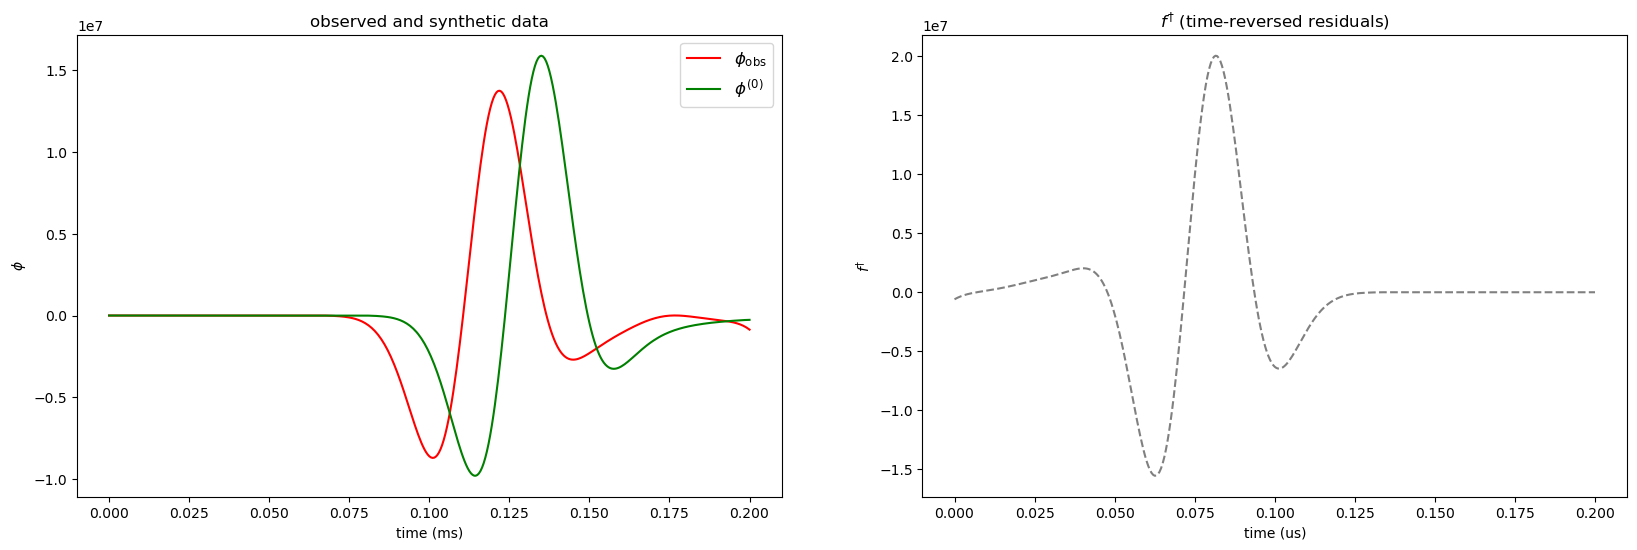

In [135]:
fig, axs = plt.subplots(1, 2, figsize=(20, 6), dpi=100)


axs[0].plot(time*1e3, phi_obs[0], color='red', label=r'$\phi_\text{obs}$')
axs[0].plot(time*1e3, phi_homo[0], color='green', label=r'$\phi^{(0)}$')

axs[0].legend(fontsize=12)
axs[0].set_xlabel('time (ms)')
axs[0].set_ylabel(r'$\phi$')
axs[0].set_title('observed and synthetic data')


axs[1].plot(time*1e3, -f_adj[0], color='gray',linestyle='--')
axs[1].set_xlabel('time (us)')
axs[1].set_ylabel(r'$f^{\dagger}$')
axs[1].set_title(r'$f^{\dagger}$ (time-reversed residuals)')


Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/11 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/14841 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/11 [00:00<?, ?it/s]

In [70]:
phi_tt_homo.t

<xarray.DataArray 't' (t: 41)> Size: 328B
array([0.00e+00, 5.00e-06, 1.00e-05, 1.50e-05, 2.00e-05, 2.50e-05, 3.00e-05,
       3.50e-05, 4.00e-05, 4.50e-05, 5.00e-05, 5.50e-05, 6.00e-05, 6.50e-05,
       7.00e-05, 7.50e-05, 8.00e-05, 8.50e-05, 9.00e-05, 9.50e-05, 1.00e-04,
       1.05e-04, 1.10e-04, 1.15e-04, 1.20e-04, 1.25e-04, 1.30e-04, 1.35e-04,
       1.40e-04, 1.45e-04, 1.50e-04, 1.55e-04, 1.60e-04, 1.65e-04, 1.70e-04,
       1.75e-04, 1.80e-04, 1.85e-04, 1.90e-04, 1.95e-04, 2.00e-04])
Coordinates:
  * t        (t) float64 328B 0.0 5e-06 1e-05 ... 0.00019 0.000195 0.0002

/home/b6as/oliverwfy.b6as/miniforge3/envs/salvus/lib/python3.11/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


(<Figure size 1100x500 with 2 Axes>,
 <Axes: title={'center': '$\\phi_{tt}$ Snapshot - Time Step: 0.05 (ms) '}, xlabel='X (m)', ylabel='Y (m)'>)

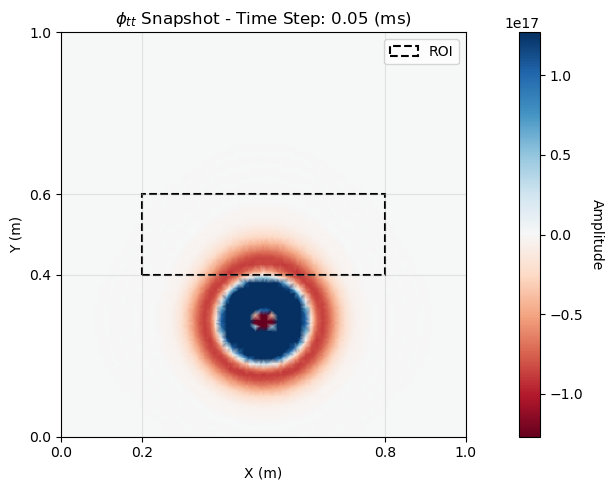

In [91]:
def roi_node_indices(mesh, x_min, x_max, y_min, y_max):
    # Assuming mesh.points is your (14841, 2) array
    points = mesh.points

    # Create a boolean mask for each condition
    # points[:, 0] is the x-coordinate, points[:, 1] is the y-coordinate
    mask = (points[:, 0] >= x_min) & (points[:, 0] <= x_max) & \
           (points[:, 1] >= y_min) & (points[:, 1] <= y_max)

    # Extract the indices where the mask is True
    node_indices = np.where(mask)[0]
    return node_indices


def plot_salvus_mesh_snapshot(mesh, wavefield, t_idx, field_name, x_lim=None, y_lim=None, title_suffix=""):
    """
    Plots a 2D snapshot of a Salvus wavefield using tripcolor.
    
    Parameters:
    mesh: The Salvus mesh object (containing .points)
    wavefield: The data array with shape (nodes, 1, time_steps)
    t_idx: The integer index of the time step to plot
    x_lim, y_lim: Tuples (min, max) defining the ROI to draw as a dashed box
    title_suffix: Optional string to add to the plot title
    """
    # 1. Extract coordinates and the specific time snapshot
    x, y = mesh.points[:, 0], mesh.points[:, 1]
    # Squeeze to handle (14841, 1, 41) -> (14841, 41) then slice time
    data_snapshot = wavefield.values.squeeze()[:, t_idx]
    # time step for title
    time_step = np.round(wavefield.t.values[t_idx]*1e3, 2)
    
    # 2. Setup Figure
    fig, ax = plt.subplots(figsize=(11, 5))
    
    # 3. Create the tripcolor plot
    # 'gouraud' provides smooth interpolation between nodes
    tp = ax.tripcolor(x, y, data_snapshot, cmap='RdBu', shading='gouraud')
    
    # 4. Handle Colorbar with symmetric limits for wavefields
    vlimit = np.percentile(np.abs(data_snapshot), 98) # Use 98th percentile to avoid outlier scaling
    tp.set_clim(-vlimit, vlimit)
    cbar = fig.colorbar(tp, ax=ax)
    cbar.set_label("Amplitude", rotation=270, labelpad=15)
    
    # 5. Draw the ROI Box if limits are provided
    if x_lim and y_lim:
        roi_rect = plt.Rectangle((x_lim[0], y_lim[0]), 
                                 x_lim[1] - x_lim[0], 
                                 y_lim[1] - y_lim[0],
                                 fill=False, color='black', linestyle='--', 
                                 linewidth=1.5, label='ROI')
        ax.add_patch(roi_rect)
        ax.legend(loc='upper right')
        
        # Set ticks to align with ROI boundaries for clarity
        ax.set_xticks(np.unique([0, x_lim[0], x_lim[1], 1.0]))
        ax.set_yticks(np.unique([0, y_lim[0], y_lim[1], 1.0]))

    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    # 6. Formatting
    ax.set_title(f"{field_name} Snapshot - Time Step: {time_step} (ms) {title_suffix}")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    return fig, ax




# roi for inversion
x_lim = (0.2, 0.8)
y_lim = (0.4, 0.6)
idx = roi_node_indices(mesh, x_lim[0], x_lim[1], y_lim[0], y_lim[1])



# Execute the plot

plot_salvus_mesh_snapshot(mesh, phi_tt_homo, t_idx=10, field_name=r'$\phi_{tt}$', x_lim=x_lim, y_lim=y_lim)

In [ ]:
roi = 


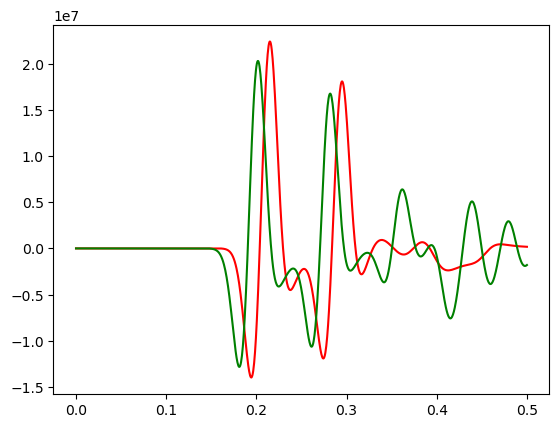

In [55]:
time = u.time
plt.plot(time*1e3, u[0], color='red', linestyle='-' ,label=rf'$c^{{(0)}}$ (Homogeneous)')
plt.plot(time*1e3, u_obs[0], color='green', linestyle='-', label=rf'$c^*$ (Layered Model)')


In [18]:
# simulation_name = 'forward_simulation_homogeneous_model'
simulation_name = 'forward_simulation_layred_model'

ed_homo = p.waveforms.get(data_name='forward_simulation_homogeneous_model', events=p.events.list()[0])[0]
ed_layered = p.waveforms.get(data_name='forward_simulation_layred_model', events=p.events.list()[0])[0]

data_homo = ed_homo.get_waveform_data_xarray(receiver_field='phi')
data_layered = ed_layered.get_waveform_data_xarray(receiver_field='phi')
time = data_homo.time


plt.figure(figsize=(12, 6))
t_idx = np.argmax(data_homo[1].values)

plt.plot(time*1e3, data_homo[0], color='red', linestyle='-' ,label=rf'$c^{{(0)}}$ (Homogeneous)')
plt.plot(time*1e3, data_layered[0], color='green', linestyle='-', label=rf'$c^*$ (Layered Model)')




# plt.plot(time*1e3-time_shift_in_seconds*1e3, data_true[1])

plt.axvline(x=math.dist(s_loc, r_loc)/VP*1e3+time[t_idx]*1e3, color='red', linestyle='--', label='ToF (1st arrival)')

plt.axvline(x=math.dist((s_loc[0], -s_loc[1]), r_loc)/VP*1e3+time[t_idx]*1e3, color='red', linestyle='--', label='ToF (2nd arrival)')
plt.legend(fontsize=12)
plt.xlabel('t (ms)', fontsize=12)
plt.ylabel(rf'$\phi$', fontsize=12)

plt.savefig(Path(IMAGE_DIR_WIN, fr'received_signals.png'))


IndexError: index 1 is out of bounds for axis 0 with size 1

<Figure size 1200x600 with 0 Axes>

In [95]:
import time

p.add_to_project(
    sn.MisfitConfiguration(
        name="L2",
        observed_data="forward_simulation_layred_model",
        misfit_function="L2",
        receiver_field='phi',
    )
)


while not p.actions.inversion.compute_misfits(
    simulation_configuration="forward_simulation_homogeneous_model", 
    misfit_configuration="L2", 
    events=p.events.list()[0],
    site_name=SITE_NAME,
    ranks_per_job = RANKS
): time.sleep(10.0)


In [96]:
while not p.actions.inversion.compute_gradients(
    simulation_configuration="forward_simulation_homogeneous_model",
    misfit_configuration="L2",
    wavefield_compression=sn.WavefieldCompression(
        forward_wavefield_sampling_interval=10
    ),
    events=p.events.list()[0],
    site_name=SITE_NAME,
    ranks_per_job=4,
): time.sleep(10.0)

p.viz.nb.gradients(
    simulation_configuration="forward_simulation_homogeneous_model",
    misfit_configuration="L2",
    wavefield_compression=sn.WavefieldCompression(
        forward_wavefield_sampling_interval=10
    ),
    events=p.events.list()[0],
)

[2026-03-18 19:05:14,385] INFO: The following events have been simulated before, but checkpoints are not available for this combination of `site_name` and `ranks_per_job` and wavefield compression settings. They will be run again: ['event_singlepair']
[2026-03-18 19:05:14,699] INFO: Submitting job ...
[2026-03-18 19:05:15,183] INFO: Launched simulations for 1 events. Please check again to see if they are finished.
[2026-03-18 19:05:24,392] INFO: Submitting job ...
[2026-03-18 19:05:24,550] INFO: Launched adjoint simulations for 1 events. Please check again to see if they are finished.


In [3]:
p.viz.nb.inversion(inverse_problem_configuration="inversion_L2")

In [4]:
mesh = p.inversions.get_model(inverse_problem_configuration="inversion_L2", iteration_id=4)
init_mesh = p.simulations.get_mesh(simulation_configuration='forward_simulation_layred_model')


In [ ]:
# shape (912,25)
mesh.element_nodal_fields['VP']

# shape (14841, 2)
mesh.points



(912, 25)

In [41]:
# Known values from your attributes
num_elements = mesh.connectivity.shape[0]  # 912
nodes_per_elem = mesh.connectivity.shape[1] # 25
num_points = mesh.points.shape[0]          # 14841

# 1. Derive the order k (nodes per side is k+1)
k = int(np.sqrt(nodes_per_elem)) - 1 # 4

# 2. Iterate through factors of num_elements to find the match
for nx in range(1, num_elements + 1):
    if num_elements % nx == 0:
        ny = num_elements // nx
        # Check if this combination yields the correct global point count
        if (nx * k + 1) * (ny * k + 1) == num_points:
            print(f"Found dimensions: nx = {nx}, ny = {ny}")
            break

Found dimensions: nx = 24, ny = 38


Text(0.5, 1.0, 'VP (Elemental Field)')

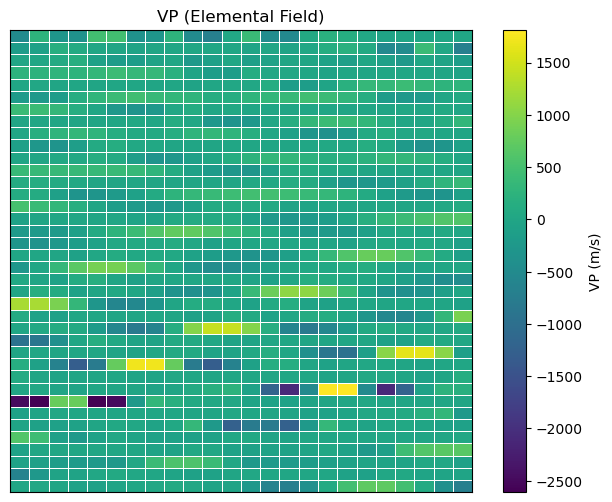

In [45]:
vp_field = np.mean(mesh.element_nodal_fields['VP'], axis=1)*5000
vp_grid = vp_field.reshape((ny, nx))

x_edges = np.linspace(0, 1, nx+1)
y_edges = np.linspace(0, 1, ny+1)

# Create high-resolution figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Plot with thicker lines
pc = ax.pcolormesh(x_edges, y_edges, vp_grid, cmap="viridis",
                   edgecolors='white', linewidth=0.5, rasterized=True)  # Thicker grid lines

# Colorbar
cbar = plt.colorbar(pc, ax=ax)
cbar.set_label("VP (m/s)")

# Hide all ticks and labels
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
# pc.set_clim(vmin=5000, vmax=6000)  # Set colorbar limits

# Keep square aspect and clean layout
ax.set_aspect("equal")
plt.title("VP (Elemental Field)")


In [46]:
vp_field

array([ 5.05917788e+00,  1.84578552e+01, -1.18519945e+01, -5.74486427e+01,
       -8.50404053e+01, -3.17109261e+01,  7.45246792e+00,  2.73485031e+01,
        6.51588364e+01,  1.70580349e+01, -4.38902473e+01, -3.70319061e+01,
       -2.53599304e+02, -6.24043457e+02, -7.18333496e+02, -4.03572662e+02,
        8.06206360e+01,  4.75386902e+02,  7.08379028e+02,  7.08383179e+02,
        4.75393311e+02,  8.06234894e+01, -4.03571960e+02, -7.18331787e+02,
       -6.24042542e+02, -2.53598145e+02, -3.70310822e+01, -4.38913460e+01,
        1.70578289e+01,  6.51589279e+01,  2.73480797e+01,  7.45216322e+00,
       -3.17109032e+01, -8.50405350e+01, -5.74489174e+01, -1.18523207e+01,
        1.84577847e+01,  5.05914450e+00,  3.45348883e+00,  1.45292549e+01,
        2.95716882e+00, -6.58442078e+01, -9.04253387e+01,  1.91536865e+01,
        4.25345726e+01, -2.03353462e+01, -2.87108192e+01, -2.14114513e+01,
       -5.25473480e+01, -1.04613129e+02, -1.61546112e+02, -2.00384964e+02,
       -2.20443787e+02, -